In [65]:
%pip install pandas matplotlib seaborn langid

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [66]:
import pandas as pd
from  roberta_sentiment import roberta_sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import langid
import unicodedata
import os

vaderAnalyzer = SentimentIntensityAnalyzer()

In [67]:


files = os.listdir('./data/')

files = ['12-13-2025_01-52.db', '12-13-2025_22-00.db']

print(files)

posts_df = pd.DataFrame()
reposts_df = pd.DataFrame()

for f in files:
    print(f)
    if not f.endswith('db'):
        continue
    con = sqlite3.connect(f'./data/{f}')
    posts = pd.read_sql('SELECT * FROM posts', con)
    posts['dataset'] = f
    reposts = pd.read_sql('SELECT * FROM reposts', con)
    reposts['dataset'] = f
    
    posts_df = pd.concat([posts_df, posts])
    reposts_df = pd.concat([reposts_df, reposts])
    con.close()

posts_df['post_time'] = pd.to_datetime(posts_df['post_time'], format = 'ISO8601')
reposts_df['repost_time'] = pd.to_datetime(reposts_df['time'], format = 'ISO8601')

print(posts_df[::100])
print(reposts_df[::100])
print(len(posts_df))
print(len(reposts_df))

['12-13-2025_01-52.db', '12-13-2025_22-00.db']
12-13-2025_01-52.db
12-13-2025_22-00.db
                                               post_cid  \
0     bafyreifp7poxws64huhasx57d4iytmlozzhyqzpjxyx2p...   
100   bafyreihunhatfka7laskxadvaswb2fsquv3ofvt5metz3...   
200   bafyreihg2m37cfxggvwvjtc47autpnwsg2pawnlhhdmvb...   
300   bafyreickjxjhyweq5owlbemmvi6fmna75r6pc4evbjnt5...   
400   bafyreievbeqxn34shdxr2c4a7rfaahjrttewg7nmo7vo6...   
...                                                 ...   
7005  bafyreicdhaofz5u5u2zs2e5z44fsmonmbew5cgbfqzhws...   
7105  bafyreifldshxekrpkkvxe62ijlfisyf3ciuohuaz5apxb...   
7205  bafyreibhzmkg4pphdpzjayxx4z5rgh26jyc5wamdihvk5...   
7305  bafyreia4q7yw5ateg24mslm73x2vkinrzjtph7mtn6h5f...   
7405  bafyreidhbpolzqoo3vbvlefjbaoyw7zn4zwxorpdqkunl...   

                                               post_uri  \
0     at://did:plc:5zngi6urpjzmmz7tcbizswji/app.bsky...   
100   at://did:plc:vtueku2qq2o6xh43lv5j5prl/app.bsky...   
200   at://did:plc:wllyn2uh

<Figure size 1000x500 with 0 Axes>

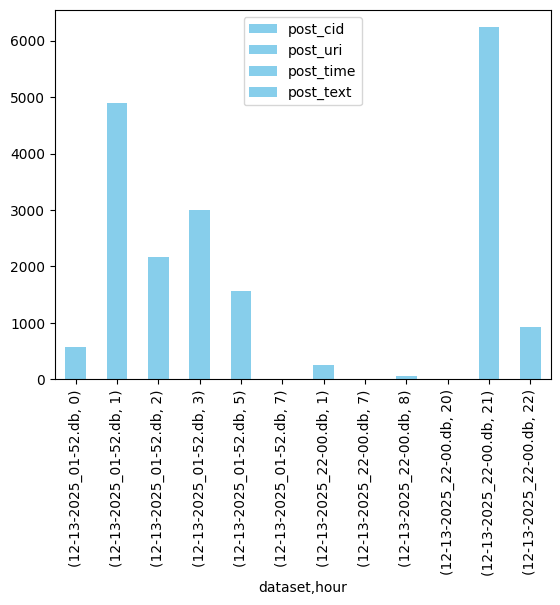

In [68]:

posts_check = posts_df.copy()
posts_check['hour'] = posts_check['post_time'].dt.hour
posts_per_hour = posts_check.groupby(['dataset', 'hour']).count()
posts_check["sentiment"] = posts_check["post_text"].apply(lambda text: vaderAnalyzer.polarity_scores(text).get('compound'))
avg_sentiment_per_hour = posts_check.groupby(['dataset', 'hour'])['sentiment'].mean()

plt.figure(figsize=(10,5))
posts_per_hour.plot(kind='bar', color='skyblue')
plt.show()




In [74]:



def to_plain(text):
    return ''.join(
        c for c in unicodedata.normalize("NFKD", text)
        if not unicodedata.combining(c)
    )



posts_df["post_text"] = posts_df["post_text"].apply(to_plain)
posts_df["lang"] = posts_df["post_text"].apply(lambda x: langid.classify(x)[0])
english_posts = posts_df[posts_df['lang'] == 'en']

first_reposts = (
    reposts_df
        .sort_values("repost_time")
        .groupby("post_cid", as_index=False)
        .first()[["post_cid", "repost_time"]]
)

merged = english_posts.merge(first_reposts, on="post_cid", how="left")




print(merged)

                                                post_cid  \
0      bafyreifp7poxws64huhasx57d4iytmlozzhyqzpjxyx2p...   
1      bafyreic5mxcx6m3e2dg7h4e24wp2q42zadauggyloxrsp...   
2      bafyreiab7lbuads2lvl7dt65ag2y4x3trofo5bprtk5vm...   
3      bafyreigqliwgmvnayyxomw4l2rwxhbq4jwrs4uw6b4drj...   
4      bafyreieekn42x4g6vnfjoyc3zd6wvs2iy3odwauzrbg4n...   
...                                                  ...   
17333  bafyreiaebwe2uxsytdyb46xpsktjcxrfdie3eme5oelfd...   
17334  bafyreigl4mc7mtof34hibtipcb7ul3hvo5xywfyb2554t...   
17335  bafyreicsn627agjc4uaxbio6umpwifyz2bznii2i6unbg...   
17336  bafyreia3ts7dw6mbt2ong2k5kc67lqzqt7ok7kz5amb5x...   
17337  bafyreifatunn3kzw52pdmqqj6aq7av75repc425bcjxvi...   

                                                post_uri  \
0      at://did:plc:5zngi6urpjzmmz7tcbizswji/app.bsky...   
1      at://did:plc:zsghsvwshxlsansdf5axrxnz/app.bsky...   
2      at://did:plc:yeoczgufzuiqr4ruo5bihg23/app.bsky...   
3      at://did:plc:soc33iew3wv4mvmjohp

In [75]:
merged.dtypes

post_cid                    object
post_uri                    object
post_time      datetime64[ns, UTC]
post_text                   object
dataset                     object
lang                        object
repost_time    datetime64[ns, UTC]
dtype: object

In [76]:
print(posts)



merged["sentiment"] = merged["post_text"].apply(lambda text: vaderAnalyzer.polarity_scores(text).get('compound'))

# Calculate time to first repost (timedelta)
merged["time_to_first_repost"] = merged["repost_time"] - merged["post_time"]

# Convert to minutes as numeric
merged["time_to_first_repost_min"] = merged["time_to_first_repost"].dt.total_seconds() / 60

# print(repost_df.info())
# print(post_df.info())
print(merged)

                                               post_cid  \
0     bafyreiehre36pydbrcafz7falncvcdsthprhmpj3rcxnt...   
1     bafyreiaw5d5hdjnjttvcauojhjotztkei7ktynfhwuo3u...   
2     bafyreifioqxknu2xch5jvfwts2ten7gcgauvo2ckzuc6n...   
3     bafyreiedqrzicdu5kdyzg6trw43qkwefbmn5ivgwerver...   
4     bafyreigthfjon3zl6gemabou4bz57pwukqwf2jaqooaff...   
...                                                 ...   
7461  bafyreiaebwe2uxsytdyb46xpsktjcxrfdie3eme5oelfd...   
7462  bafyreigl4mc7mtof34hibtipcb7ul3hvo5xywfyb2554t...   
7463  bafyreicsn627agjc4uaxbio6umpwifyz2bznii2i6unbg...   
7464  bafyreia3ts7dw6mbt2ong2k5kc67lqzqt7ok7kz5amb5x...   
7465  bafyreifatunn3kzw52pdmqqj6aq7av75repc425bcjxvi...   

                                               post_uri  \
0     at://did:plc:gumofi6r5hnuq7uexqtjj5y5/app.bsky...   
1     at://did:plc:5glnbrxsqhmslklqosmstdru/app.bsky...   
2     at://did:plc:5v7ye5r67tbs2vkl2ohp5d44/app.bsky...   
3     at://did:plc:rw3l5tczgx5pivpxd7ke3kx6/app.bsky...

In [77]:
merged.dtypes

post_cid                                 object
post_uri                                 object
post_time                   datetime64[ns, UTC]
post_text                                object
dataset                                  object
lang                                     object
repost_time                 datetime64[ns, UTC]
sentiment                               float64
time_to_first_repost            timedelta64[ns]
time_to_first_repost_min                float64
dtype: object

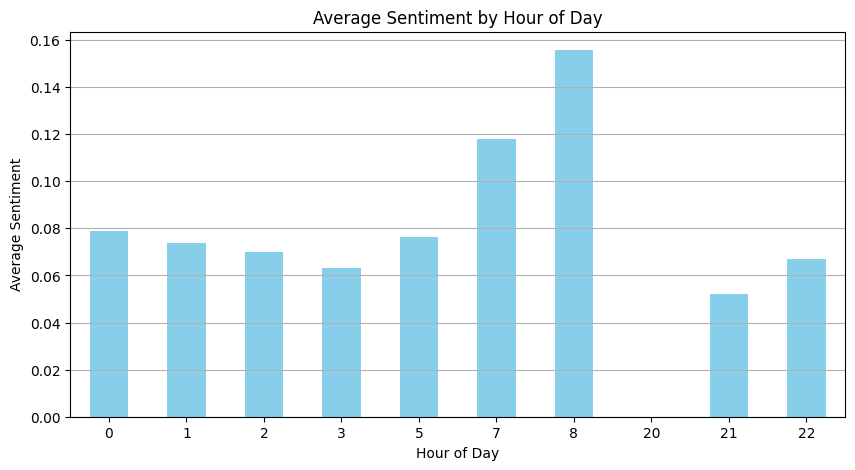

In [78]:
df = merged

df['hour'] = df['post_time'].dt.hour

# 2. Group by hour and compute average sentiment
avg_sentiment_by_hour = df.groupby('hour')['sentiment'].mean()

# 3. Plot
plt.figure(figsize=(10,5))
avg_sentiment_by_hour.plot(kind='bar', color='skyblue')
plt.xlabel('Hour of Day')
plt.ylabel('Average Sentiment')
plt.title('Average Sentiment by Hour of Day')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

all posts: 17338
after no repost remover: 17338
after no reposts remover: 1285
after negative remover: 1281


C:\Users\milov\AppData\Local\Temp\ipykernel_21808\1624930462.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_time = df_plot.groupby("sentiment_bin")["time_to_first_repost_min"].mean().reset_index()


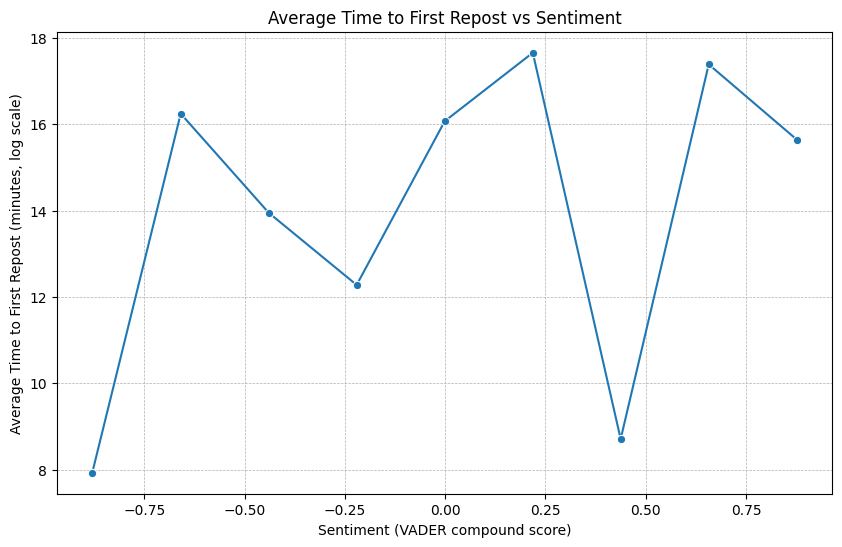

C:\Users\milov\AppData\Local\Temp\ipykernel_21808\1624930462.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = df_plot.groupby("sentiment_bin").size().reset_index(name="count")


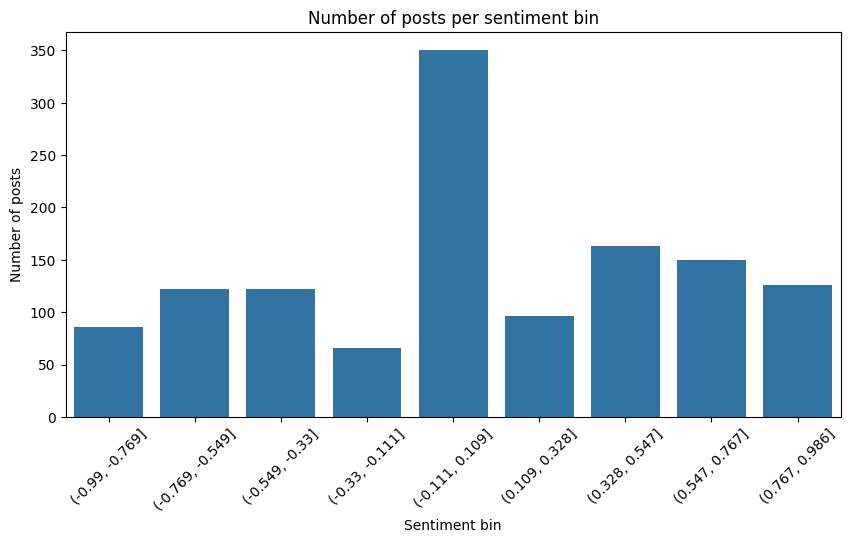

1281


In [79]:
print(f'all posts: {len(merged)}')
# Remove posts without reposts

print(f'after no repost remover: {len(merged)}')
# Optional: also remove NaN values just to be safe
merged = merged.dropna(subset=["time_to_first_repost_min"])


print(f'after no reposts remover: {len(merged)}')
# Remove rows with negative time_to_first_repost_min
merged = merged[merged["time_to_first_repost_min"] >= 0]
print(f'after negative remover: {len(merged)}')

df_plot = merged.dropna(subset=["time_to_first_repost_min"])


# Optionally, bin sentiment scores into ranges
# VADER sentiment ranges from -1 to 1
num_bins = 9
df_plot["sentiment_bin"] = pd.cut(df_plot["sentiment"], bins=num_bins)

# Compute average time to first repost per sentiment bin
avg_time = df_plot.groupby("sentiment_bin")["time_to_first_repost_min"].mean().reset_index()

# For plotting, use the midpoint of each bin
avg_time["sentiment_mid"] = avg_time["sentiment_bin"].apply(lambda x: x.mid)

# Plot line graph
plt.figure(figsize=(10,6))
sns.lineplot(x="sentiment_mid", y="time_to_first_repost_min", data=avg_time, marker="o")
plt.xlabel("Sentiment (VADER compound score)")
plt.ylabel("Average Time to First Repost (minutes, log scale)")
plt.title("Average Time to First Repost vs Sentiment")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()

# Count the number of posts per bin
bin_counts = df_plot.groupby("sentiment_bin").size().reset_index(name="count")

plt.figure(figsize=(10,5))
sns.barplot(x="sentiment_bin", y="count", data=bin_counts)
plt.xticks(rotation=45)
plt.xlabel("Sentiment bin")
plt.ylabel("Number of posts")
plt.title("Number of posts per sentiment bin")
plt.show()

print(len(merged))

In [ ]:
bin7 = merged[merged['sentiment'].between(0.328, 0.547)]
print(len(bin7))

bin7.dtypes
for i in bin7:
    print(i[0])

    #print(f'{i[9]} -> {i[3]}')

163


IndexError: string index out of range

C:\Users\milov\AppData\Local\Temp\ipykernel_21808\1527140384.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("sentiment_bin")["time_to_first_repost_min"]


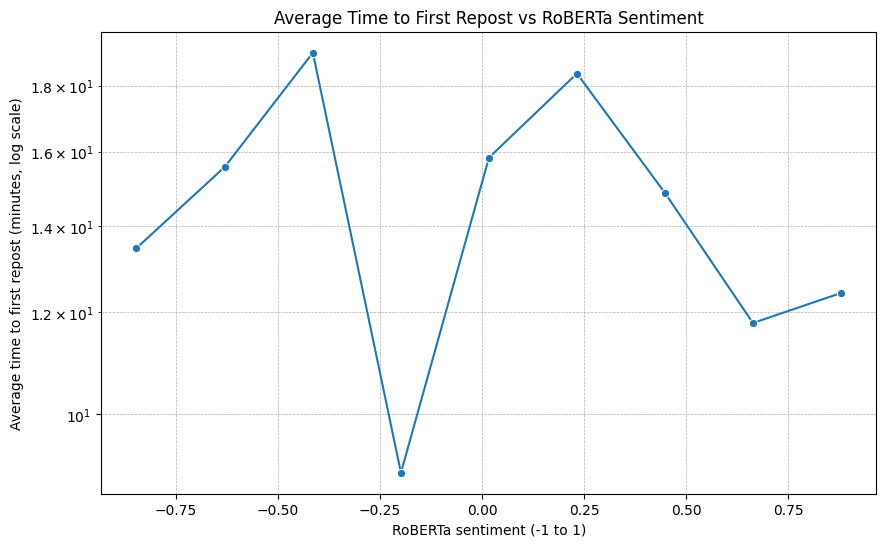

In [80]:
def safe_roberta(text):
    try:
        return roberta_sentiment(str(text)[:500])
    except Exception as e:
        print("Error for post:", text[:50], "…", e)
        return None  # or 0 if you prefer

# 1. Compute RoBERTa sentiment for each post
merged["roberta_sentiment"] = merged["post_text"].apply(safe_roberta)

# 2. Ensure time-to-first-repost in minutes
merged["time_to_first_repost_min"] = (merged["repost_time"] - merged["post_time"]).dt.total_seconds() / 60

# 3. Remove invalid or negative times
df_plot = merged.dropna(subset=["roberta_sentiment", "time_to_first_repost_min"])
df_plot = df_plot[df_plot["time_to_first_repost_min"] >= 0]

# 4. Bin sentiment and compute average repost time per bin
num_bins = 9
df_plot["sentiment_bin"] = pd.cut(df_plot["roberta_sentiment"], bins=num_bins)

avg_time = (
    df_plot
    .groupby("sentiment_bin")["time_to_first_repost_min"]
    .mean()
    .reset_index()
)
avg_time["sentiment_mid"] = avg_time["sentiment_bin"].apply(lambda x: x.mid)

# 5. Plot line: average time to first repost vs RoBERTa sentiment
plt.figure(figsize=(10,6))
sns.lineplot(
    x="sentiment_mid",
    y="time_to_first_repost_min",
    data=avg_time,
    marker="o"
)
plt.yscale("log")  # optional log scale for wide range
plt.xlabel("RoBERTa sentiment (-1 to 1)")
plt.ylabel("Average time to first repost (minutes, log scale)")
plt.title("Average Time to First Repost vs RoBERTa Sentiment")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()